**Preparando nuestras herraminetas y entorno de negocio**

In [9]:
import pandas as pd #convierte archivos en tablas inteligentes
import seaborn as sns #graficos mas bonitos
import matplotlib.pyplot as plt #graficos
import numpy as np # calculos matematicos



In [10]:
#configuramos la estetica progesional para los graficos
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize']=(12,6)
print("herramientas listas. Generando fatos de la empresa 'TechCorp'...")

#Generacion de un dataset multivariable complejo (1000 empleados)
np.random.seed(42) #datos aleatorios y 42 es la semilla para que salgan similar
n_empleados=1000
df_hr= pd.DataFrame({
    'ID_Empleado':range(1,n_empleados+1),
    'Departamento':np.random.choice(['Ingenieria', 'Ventas', 'Marketing', 'Directivos'], n_empleados, p=[0.5, 0.3,  0.15, 0.05]), #p= define un estado de probabilidad en las variables
    'Edad' : np.random.normal(34, 8, n_empleados).astype(int),
    'Años_Experiencia': np.random.normal(8, 4, n_empleados).clip(0, 40).astype(int),#astype: lo obligo a que sea entero entonces si me da 1.1, daria 1 año o asi
    'Puntaje_Desempeño': np.random.normal(75, 12, n_empleados).clip(0, 100).round(1), #clip: es un rango
})

#salario base dependiendo del departamento
salario_base = {'Ingenieria': 6000, 'Ventas': 4000, 'Marketing': 4500, 'Directivos': 15000}
df_hr['Salario_USD'] = df_hr['Departamento'].map(salario_base) + (df_hr['Años_Experiencia'] * 200) + np.random.normal(0, 500, n_empleados)

#inyectamos outliers reales (CEOs con salarios exorbitantes)
outlier_idx=df_hr[df_hr['Departamento']=='Directivos'].sample(5).index #sample: generar una muestra
df_hr.loc[outlier_idx, 'Salario_USD']=[150000, 280000, 320000, 190000, 450000]

df_hr['Salario_USD'] = df_hr['Salario_USD'].round(2)

display(df_hr.head())
print(f'\nDataset generado con {df_hr.shape[0]} filas y {df_hr.shape[1]} columnas.')

herramientas listas. Generando fatos de la empresa 'TechCorp'...


,ID_Empleado,Departamento,Edad,Años_Experiencia,Puntaje_Desempeño,Salario_USD
0,1,Ingenieria,35,2,85.5,6324.84
1,2,Directivos,23,7,67.2,16236.65
2,3,Ventas,37,1,60.6,3678.71
3,4,Ventas,38,11,62.5,5613.88
4,5,Ingenieria,38,8,69.2,7832.18



Dataset generado con 1000 filas y 6 columnas.


In [ ]:
print(df_hr['Edad'][0]) # para llamar solo la variable edad y poner el primer dato de esta variable

35


#Medidas de Tendencia central : Buscando el 'centro de gravedad'

In [ ]:
media_edad=df_hr['Edad'].mean() #mean:media
media_salario=df_hr['Salario_USD'].median()

print(f'La edad promedio de la empresa es de {media_edad:.1f} años.') # 1f: formato float con un solo decimal
print(f'El salario medio de la empresa es de ${media_salario:.2f}. USD') #2f : formato float con 2 decimales

La edad promedio de la empresa es de 34.3 años.
El salario medio de la empresa es de $6695.12. USD


--- EL EFECTO GRAVEDAD DE LOS MILLONARIOS---
La media (PROMEDIO MATEMATICO): $8,378.46.USD
La mediana (El empleado del medio): $6,695.12.USD

¿Notan la diferencia? ¡El promedio es engañoso! Parece que todos ganan casi 9 mil dolares


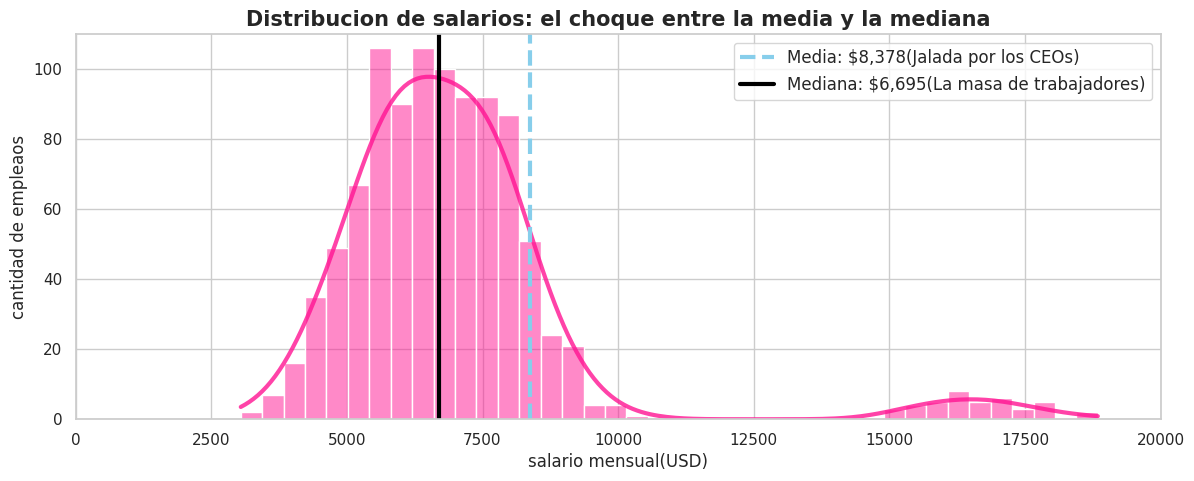

In [ ]:
#1. calculos matematicos
media_salario=df_hr['Salario_USD'].mean()
mediana_salario=df_hr['Salario_USD'].median() #mediana

#imprimimos la advertencia inicial
print('--- EL EFECTO GRAVEDAD DE LOS MILLONARIOS---')
print(f'La media (PROMEDIO MATEMATICO): ${media_salario:,.2f}.USD')
print(f'La mediana (El empleado del medio): ${mediana_salario:,.2f}.USD')
print('\n¿Notan la diferencia? ¡El promedio es engañoso! Parece que todos ganan casi 9 mil dolares')

#Visualizacion profesional: Impacto del outlier con envolvente
plt.figure(figsize=(14, 5))

#TRUCO DE PROFESOR: Filtramos visualmente los datos menores a 35,000 para que
#la 'montaña' (envolvente) se dibuje correctamente y no se aplaste por la escala
datos_visuales = df_hr[df_hr['Salario_USD']< 35000] #aqui filtramos para que nos salga salario apartir de 35 mil porque los valores de salario son muy altos y es para que lo alcancemos a visualizar

#Dibujamos el histograma y encendemos la envolvente con kde=True
sns.histplot(datos_visuales['Salario_USD'], bins=40, color='deeppink', kde=True, #linea de densidad: buscar una distribucion de densidad (linea del grafico), forma visual para arreglar el histograma
             line_kws={'linewidth': 3, 'color': 'navy', 'alpha': 0.8}) #destacamos la envolvente en azul oscuro

#Dibujamos las lineas marcadoras (usando la media real con todos los outliers)
plt.axvline(media_salario, color='skyblue', linestyle='dashed', linewidth= 3, label=f'Media: ${media_salario:,.0f}(Jalada por los CEOs)')
plt.axvline(mediana_salario, color='black', linestyle='solid', linewidth= 3, label=f'Mediana: ${mediana_salario:,.0f}(La masa de trabajadores)')

plt.title('Distribucion de salarios: el choque entre la media y la mediana', fontsize=15, fontweight='bold')
plt.xlabel('salario mensual(USD)')
plt.ylabel('cantidad de empleaos')
plt.xlim(0,20000)
plt.ylim(0,110)
plt.legend(fontsize=12) #tamaño de fuente para la leyenda
plt.show()

--- EL EFECTO GRAVEDAD DE LOS MILLONARIOS---
La media (PROMEDIO MATEMATICO): 34.30.
La mediana (El empleado del medio): 34.00.

¿Notan la diferencia? ¡El promedio es engañoso! Parece que todos ganan casi 9 mil dolares


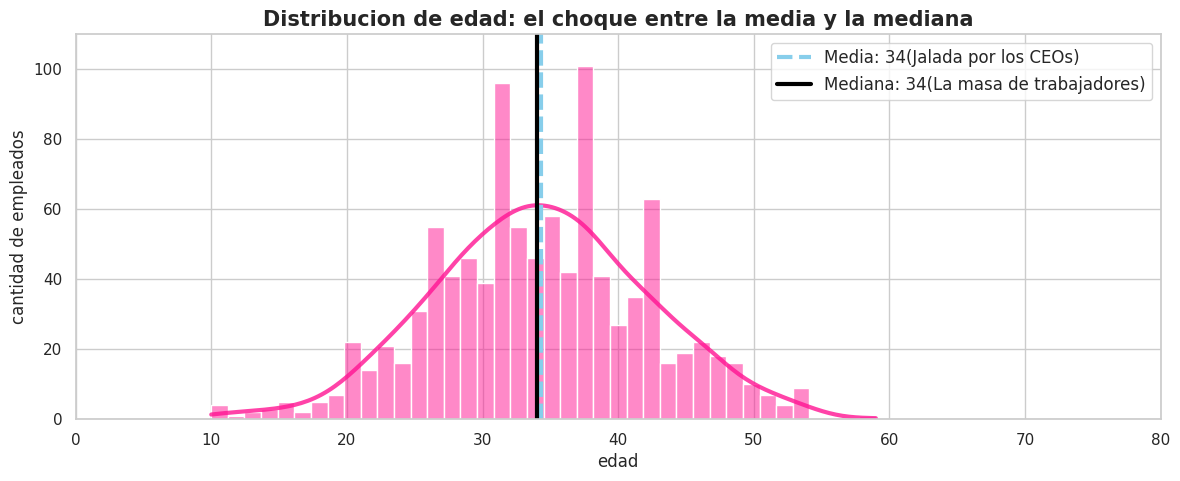

In [ ]:
#1. calculos matematicos
media_Edad=df_hr['Edad'].mean()
mediana_Edad=df_hr['Edad'].median() #mediana

#imprimimos la advertencia inicial
print('--- EL EFECTO GRAVEDAD DE LOS MILLONARIOS---')
print(f'La media (PROMEDIO MATEMATICO): {media_Edad:,.2f}.')
print(f'La mediana (El empleado del medio): {mediana_Edad:,.2f}.')
print('\n¿Notan la diferencia? ¡El promedio es engañoso! Parece que todos ganan casi 9 mil dolares')

#Visualizacion profesional: Impacto del outlier con envolvente
plt.figure(figsize=(14, 5))

#Dibujamos el histograma y encendemos la envolvente con kde=True
sns.histplot(df_hr['Edad'], bins=40, color='deeppink', kde=True, #linea de densidad: buscar una distribucion de densidad (linea del grafico), forma visual para arreglar el histograma
             line_kws={'linewidth': 3, 'color': 'navy', 'alpha': 0.8}) #destacamos la envolvente en azul oscuro

#Dibujamos las lineas marcadoras (usando la media real con todos los outliers)
plt.axvline(media_Edad, color='skyblue', linestyle='dashed', linewidth= 3, label=f'Media: {media_Edad:,.0f}(Jalada por los CEOs)')
plt.axvline(mediana_Edad, color='black', linestyle='solid', linewidth= 3, label=f'Mediana: {mediana_Edad:,.0f}(La masa de trabajadores)')

plt.title('Distribucion de edad: el choque entre la media y la mediana', fontsize=15, fontweight='bold')
plt.xlabel('edad')
plt.ylabel('cantidad de empleados')
plt.xlim(0,80)
plt.ylim(0,110)
plt.legend(fontsize=12) #tamaño de fuente para la leyenda
plt.show()

#Medidas de variabilidad: cuantificando el caos

In [ ]:
#comparamos la variabilidad de la edad por departamento
dept_stats = df_hr.groupby('Departamento')['Edad'].agg(['mean', 'std']).round(2) #vaya a la variable departamento donde estara ventas.. etc y luego saqume el puntaje desempeño de dos datos, media y desviacion estandar de cada una de las variables
dept_stats.columns = ['Media_Edad', 'Desviacion_Estandar (Riesgo)']
display(dept_stats)

,Media_Edad,Desviacion_Estandar (Riesgo)
Departamento,,
Directivos,33.28,7.49
Ingenieria,34.44,7.76
Marketing,33.81,8.41
Ventas,34.46,7.96


In [ ]:
dept_stats = df_hr.groupby('Departamento')['Puntaje_Desempeño'].agg(['mean', 'std']).round(2) #vaya a la variable departamento donde estara ventas.. etc y luego saqume el puntaje desempeño de dos datos, media y desviacion estandar de cada una de las variables
dept_stats.columns = ['Media_Desempeño', 'Desviacion_Estandar (Riesgo)']
display(dept_stats)

,Media_Desempeño,Desviacion_Estandar (Riesgo)
Departamento,,
Directivos,75.67,11.93
Ingenieria,75.32,12.22
Marketing,74.19,12.55
Ventas,74.02,12.16


In [ ]:
dept_stats = df_hr.groupby('Departamento')['Salario_USD'].agg(['mean', 'std']).round(2) #vaya a la variable departamento donde estara ventas.. etc y luego saqume el puntaje desempeño de dos datos, media y desviacion estandar de cada una de las variables
dept_stats.columns = ['Media_Salario', 'Desviacion_Estandar (Riesgo)']
display(dept_stats)

,Media_Salario,Desviacion_Estandar (Riesgo)
Departamento,,
Directivos,45018.81,89444.52
Ingenieria,7446.65,930.13
Marketing,6068.61,850.60
Ventas,5481.30,888.94


/tmp/ipykernel_829/2642400077.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Departamento', y='Puntaje_Desempeño', data=df_hr, alpha=0.6, jitter=True, palette='Set1')


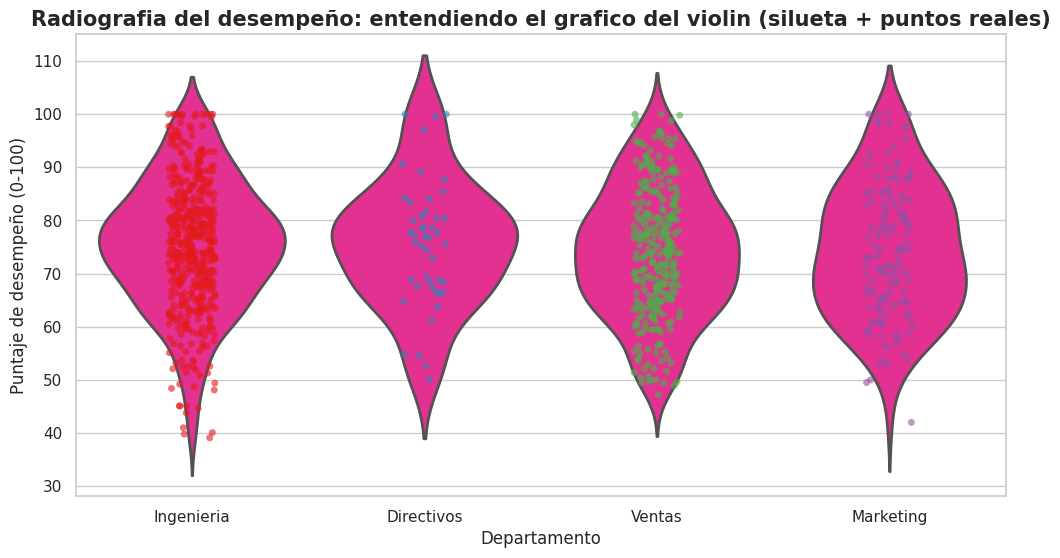

In [ ]:
#visualizacion didactica: violin plot revelado (superponiendo los puntos reales)
plt.figure(figsize=(12, 6))

#Dibujamos el violin 'transparente' (la silueta)
sns.violinplot(x='Departamento', y='Puntaje_Desempeño', data=df_hr, color = 'deeppink', inner =None, linewidth =2) #los inner se dibuja es con rayas entonces las quite para ponerle los puntos n el siguiente codigo
#linewidth: lo ancho o delgado que se ven las lineas

#Superponemos a los empleados reales (los punto de colores)
sns.stripplot(x='Departamento', y='Puntaje_Desempeño', data=df_hr, alpha=0.6, jitter=True, palette='Set1') #dibuja los puntos
#jitter:True - es para poder diferenciar los puntos , si pongo false me pondrian todos en una sola linea  y no se podria distinguir

plt.title('Radiografia del desempeño: entendiendo el grafico del violin (silueta + puntos reales)', fontsize=15, fontweight='bold')
plt.ylabel('Puntaje de desempeño (0-100)')
plt.show()
#entre mas gorda hay mas desviacion estandar y si los datos fueran delgados la desviacion estandar
#cada puntico significa la cantidad de trabajadores que hay por cada variable

/tmp/ipykernel_829/37812611.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Departamento', y='Edad', data=df_hr, alpha=0.6, jitter=True, palette='Set1') #dibuja los puntos


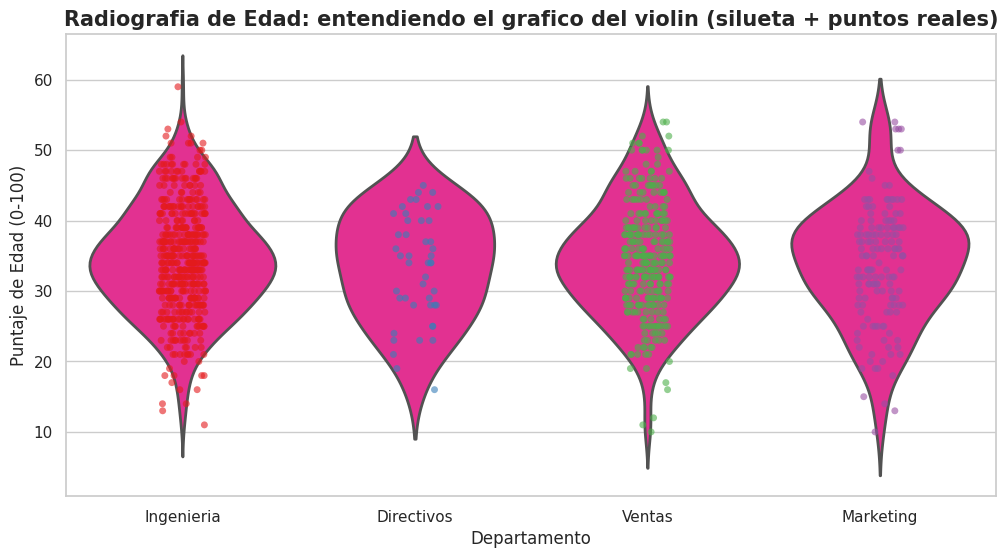

In [ ]:
#visualizacion didactica: violin plot revelado (superponiendo los puntos reales)
plt.figure(figsize=(12, 6))

#Dibujamos el violin 'transparente' (la silueta)
sns.violinplot(x='Departamento', y='Edad', data=df_hr, color = 'deeppink', inner =None, linewidth =2) #los inner se dibuja es con rayas entonces las quite para ponerle los puntos n el siguiente codigo
#linewidth: lo ancho o delgado que se ven las lineas

#Superponemos a los empleados reales (los punto de colores)
sns.stripplot(x='Departamento', y='Edad', data=df_hr, alpha=0.6, jitter=True, palette='Set1') #dibuja los puntos
#jitter:True - es para poder diferenciar los puntos , si pongo false me pondrian todos en una sola linea  y no se podria distinguir

plt.title('Radiografia de Edad: entendiendo el grafico del violin (silueta + puntos reales)', fontsize=15, fontweight='bold')
plt.ylabel('Puntaje de Edad (0-100)')
plt.show()
#entre mas gorda hay mas desviacion estandar y si los datos fueran delgados la desviacion estandar
#cada puntico significa la cantidad de trabajadores que hay por cada variable

/tmp/ipykernel_829/4143498241.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Departamento', y='Salario_USD', data=datos_visuales, alpha=0.6, jitter=True, palette='Set1') #dibuja los puntos


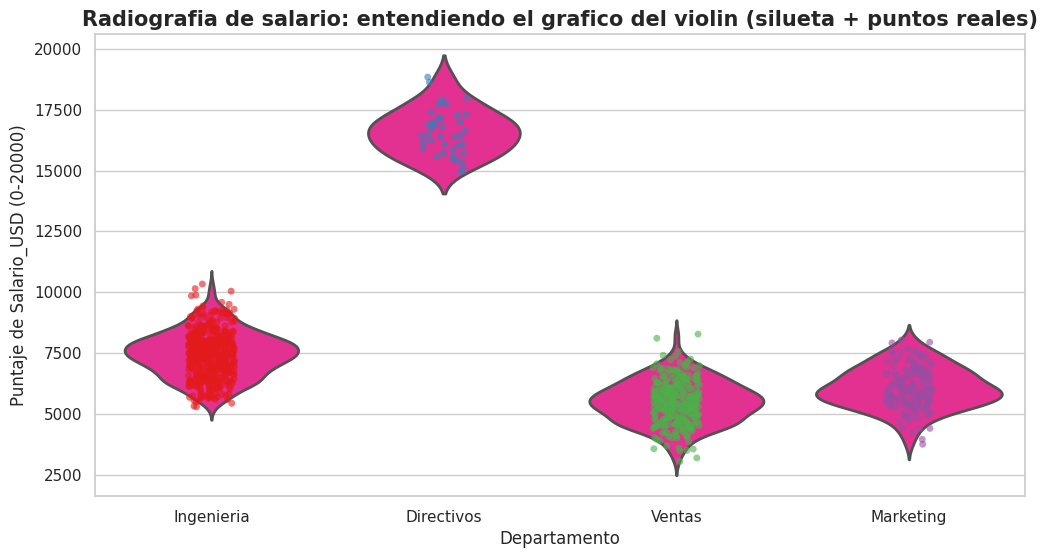

In [ ]:
datos_visuales = df_hr[df_hr['Salario_USD']< 35000] #aqui filtramos para que nos salga salario apartir de 35 mil porque los valores de salario son muy altos y es para que lo alcancemos a visualizar
#visualizacion didactica: violin plot revelado (superponiendo los puntos reales)
plt.figure(figsize=(12, 6))

#Dibujamos el violin 'transparente' (la silueta)
sns.violinplot(x='Departamento', y='Salario_USD', data=datos_visuales, color = 'deeppink', inner =None, linewidth =2) #los inner se dibuja es con rayas entonces las quite para ponerle los puntos n el siguiente codigo
#linewidth: lo ancho o delgado que se ven las lineas

#Superponemos a los empleados reales (los punto de colores)
sns.stripplot(x='Departamento', y='Salario_USD', data=datos_visuales, alpha=0.6, jitter=True, palette='Set1') #dibuja los puntos
#jitter:True - es para poder diferenciar los puntos , si pongo false me pondrian todos en una sola linea  y no se podria distinguir

plt.title('Radiografia de salario: entendiendo el grafico del violin (silueta + puntos reales)', fontsize=15, fontweight='bold')
plt.ylabel('Puntaje de Salario_USD (0-20000)')
plt.show()
#entre mas gorda hay mas desviacion estandar y si los datos fueran delgados la desviacion estandar
#cada puntico significa la cantidad de trabajadores que hay por cada variable

In [1]:
print('EXPLICACION VISUAL:')
print('-cada punto de color es una persona (un empleado).')
print('-la sombra gris de ondo (el violin) es como una funda que se adapta a donde esta la gente')
print('-si el violin es gordo en el medio: hay mucha gente amontonada ahi. Eso es baja variabilidad.')
print('-si el violin es AlTO y DELGADO: la gente esta muy dispersa. Eso significa alta desviacion estandar')

#variabilidad (dispersion): indica que tan alejados estan los datos entre si y respecto al valor central
#desviacion estandar: es la raiz cuadrada de la varianza. Representa el promedio de las desviaciones de cada dato respecto a la media

EXPLICACION VISUAL:
-cada punto de color es una persona (un empleado).
-la sombra gris de ondo (el violin) es como una funda que se adapta a donde esta la gente
-si el violin es gordo en el medio: hay mucha gente amontonada ahi. Eso es baja variabilidad.
-si el violin es AlTO y DELGADO: la gente esta muy dispersa. Eso significa alta desviacion estandar


#MEDIDAS DE POSICION Y LA ANATOMIA DEL BOXPLOT


# mirar fotos

--RADIOGRAFIA DE LAS EDADES EN LA EMPRESA
1. El Q1 (inicio de la caja) es:29.000000 años. El 25% de la empresa es menor a esto
2. El Q3 (fin de la caja) es:39.000000 años. El 75% de la empresa es menor a esto
3. La masa principal (el IQR o tamaño de la caja) esta entre 29.000000 y 39.000000 años.
4. ¡alerta de outlier! segun la regla matematica, cualquier edad mayor a 54.000000 años es atipica.

5. mediana es: 34.000000 años


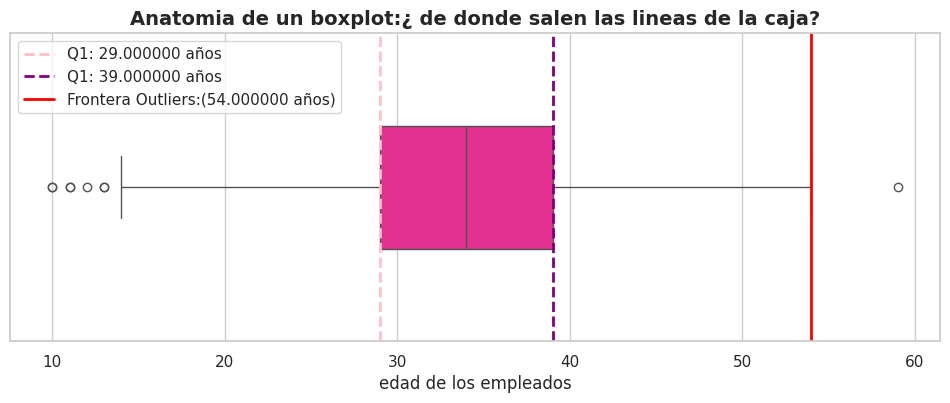

EXPLICACION
-vean como la caja rosada empieza exactamente en la linea azul (Q1) y termina en la morada (Q3)
-el bigote derecho intenta llegar hasta el dato mas lejano, pero choca contra la pared roja (limite superior)
Cualquier puntito negro que caiga a la derecha de la pared roja es un outlier.

------------------------------------------------------------


In [23]:
#PARTE 1 LA ANATOMIA MATEMATICA Y VISUAL DEL BOXPLOT (USANDO LA EDAD)

#Calculos matematicos paso a paso
Q1= df_hr['Edad'].quantile(0.25)
Mediana = df_hr['Edad'].median()
Q3= df_hr['Edad'].quantile(0.75)
IQR = Q3-Q1
limite_superior = Q3 + 1.5*IQR
limite_inferior = Q1 - 1.5*IQR
#cuartiles de 0.25 a 0.75 que es el siguiente para sacar limite superior e inferior de este rango

#Imprimimos el 'guion' para la clase
print('--RADIOGRAFIA DE LAS EDADES EN LA EMPRESA')
print(f'1. El Q1 (inicio de la caja) es:{Q1:0f} años. El 25% de la empresa es menor a esto')
print(f'2. El Q3 (fin de la caja) es:{Q3:0f} años. El 75% de la empresa es menor a esto')
print(f'3. La masa principal (el IQR o tamaño de la caja) esta entre {Q1:0f} y {Q3:0f} años.')
print(f'4. ¡alerta de outlier! segun la regla matematica, cualquier edad mayor a {limite_superior:0f} años es atipica.\n')
print(f'5. mediana es: {Mediana:0f} años')


#Visualizacion didactica: dibujando las formulas
plt.figure(figsize=(12, 4))
sns.boxplot(x=df_hr['Edad'], color='deeppink', width=0.4)

#Trazamos lineas verticales para conectar los numeros con el dibujo
plt.axvline(Q1, color='pink', linestyle='--', linewidth=2, label=f'Q1: {Q1:0f} años')
plt.axvline(Q3, color='purple', linestyle='--', linewidth=2, label=f'Q1: {Q3:0f} años')
plt.axvline(limite_superior, color='red', linestyle='-', linewidth=2, label=f'Frontera Outliers:({limite_superior:0f} años)') #axv linea vertical

plt.title('Anatomia de un boxplot:¿ de donde salen las lineas de la caja?', fontsize=14, fontweight='bold')
plt.xlabel('edad de los empleados')
plt.legend()
plt.show()

print('EXPLICACION')
print('-vean como la caja rosada empieza exactamente en la linea azul (Q1) y termina en la morada (Q3)')
print('-el bigote derecho intenta llegar hasta el dato mas lejano, pero choca contra la pared roja (limite superior)')
print('Cualquier puntito negro que caiga a la derecha de la pared roja es un outlier.\n')
print('-'*60)



<Axes: xlabel='Departamento', ylabel='Edad'>

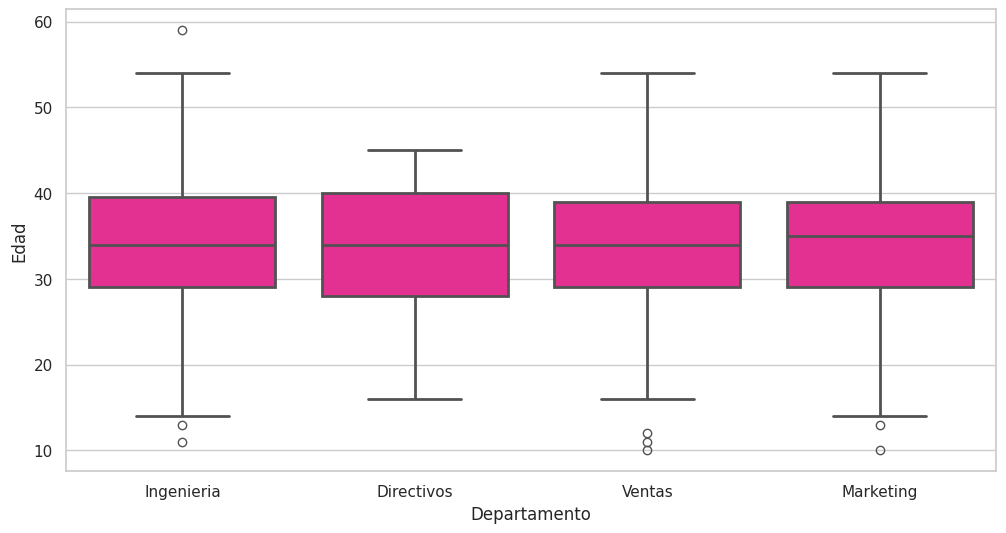

In [34]:
sns.boxplot(x='Departamento',y='Edad', color='deeppink', data=datos_visuales, linewidth =2)

<Axes: xlabel='Departamento', ylabel='Salario_USD'>

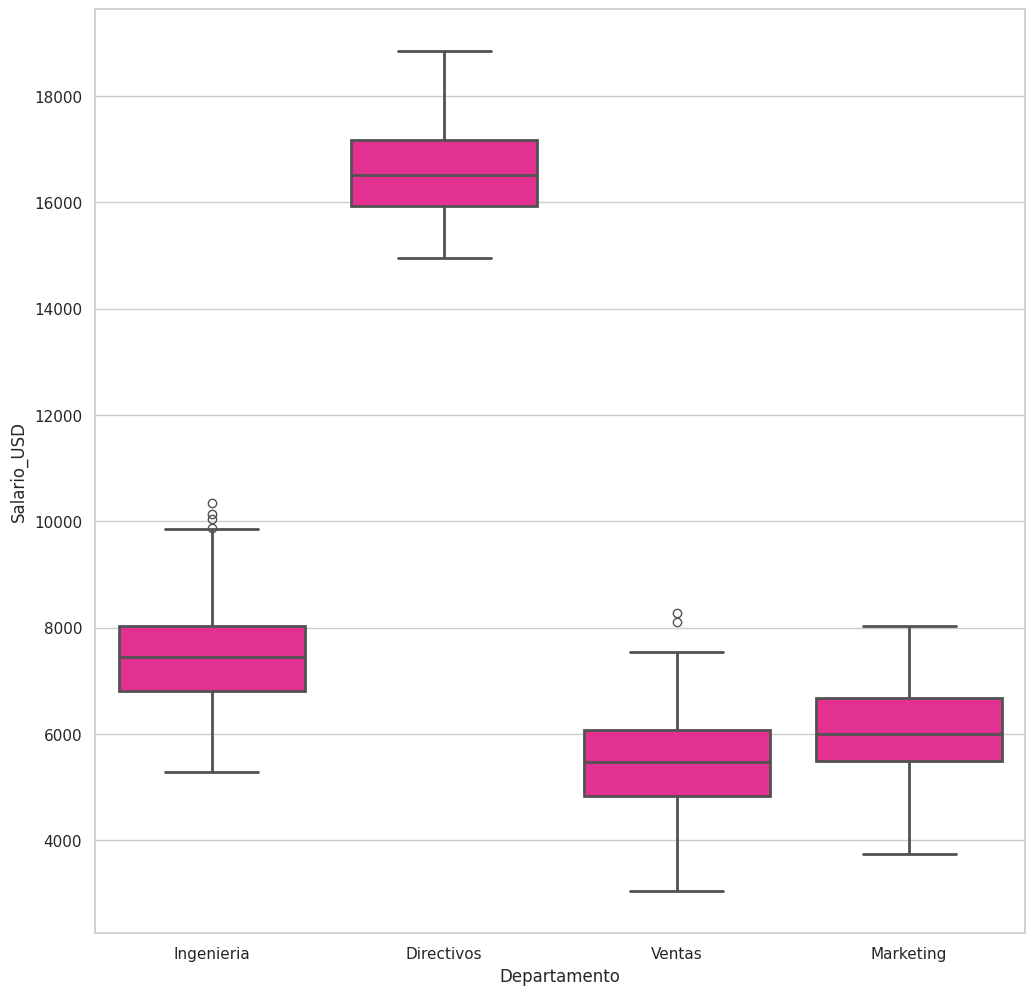

In [33]:
#Visualizacion didactica: dibujando las formulas
plt.figure(figsize=(12, 12))
datos_visuales = df_hr[df_hr['Salario_USD']< 35000]
sns.boxplot(x='Departamento',y='Salario_USD', color='deeppink', data=datos_visuales, linewidth =2)


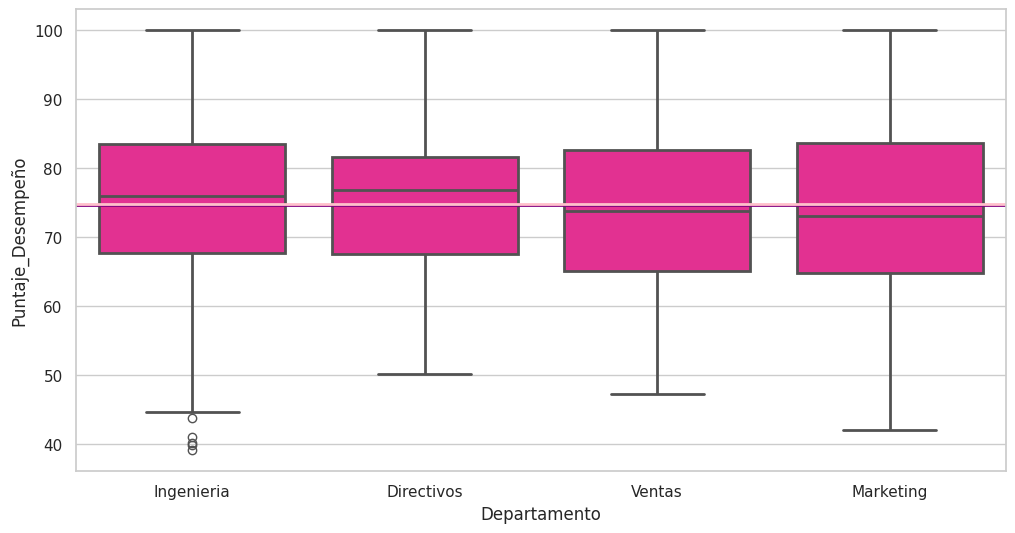

In [41]:
sns.boxplot(x='Departamento',y='Puntaje_Desempeño', color='deeppink', data=datos_visuales, linewidth =2)
Mediana = df_hr['Puntaje_Desempeño'].median()
Media = df_hr['Puntaje_Desempeño'].mean()
plt.axhline(Mediana, color='purple', linestyle='-', linewidth=2, label=f'Mediana:({Mediana:0f} )') #axh horizontal inea
plt.axhline(Media, color='pink', linestyle='-', linewidth=2, label=f'Media:({Media:0f} )')